In [17]:
# ==============================================================================
# CELL 1: ENVIRONMENT SETUP & IMPORTS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.impute import SimpleImputer
import warnings

# Suppress warnings for a clean output
warnings.filterwarnings('ignore')

# Set professional visualization aesthetics
sns.set_theme(style="whitegrid", context="talk")
colors = ['#2ecc71', '#e74c3c'] # Green for Low Risk, Red for High Risk

print("✅ Libraries successfully imported and environment configured.")

✅ Libraries successfully imported and environment configured.


In [18]:
# ==============================================================================
# CELL 2: SYNTHETIC CLINICAL DATA GENERATION
# ==============================================================================
print("Generating Simulated Clinical Fall Risk Dataset (100,000 Records)...")

np.random.seed(42)
n_patients = 100000

# Demographics
age = np.random.normal(loc=74, scale=10, size=n_patients).clip(50, 100)
bmi = np.random.normal(loc=26, scale=6, size=n_patients).clip(15, 45)

# Clinical Variables (Morse Fall Scale & Geriatric Factors)
history_of_falls = np.random.choice([0, 1], size=n_patients, p=[0.75, 0.25])
secondary_diagnosis = np.random.choice([0, 1], size=n_patients, p=[0.35, 0.65])
ambulatory_aid = np.random.choice([0, 1, 2], size=n_patients, p=[0.55, 0.35, 0.10])
iv_therapy = np.random.choice([0, 1], size=n_patients, p=[0.85, 0.15])
mental_status = np.random.choice([0, 1], size=n_patients, p=[0.80, 0.20])
medications_count = np.random.poisson(lam=5, size=n_patients).clip(0, 18)
vision_impairment = np.random.choice([0, 1], size=n_patients, p=[0.7, 0.3])
osteoporosis = np.random.choice([0, 1], size=n_patients, p=[0.6, 0.4])

# Gait Status (Correlated with other risks)
gait_status = np.zeros(n_patients)
high_risk_group = (age > 75) | (osteoporosis == 1) | (history_of_falls == 1)
gait_status[high_risk_group] = np.random.choice([1, 2], size=np.sum(high_risk_group), p=[0.7, 0.3])

# Calculate Hidden Risk Score
risk_score = (
    (age * 0.04) + (history_of_falls * 3.0) + (secondary_diagnosis * 1.0) +
    (ambulatory_aid * 1.5) + (iv_therapy * 0.5) + (gait_status * 2.0) +
    (mental_status * 2.5) + (medications_count * 0.3) +
    (vision_impairment * 1.2) + (osteoporosis * 1.5)
)

# Normalize and Create Target Class
risk_probability = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())
target_class = (risk_probability > 0.60).astype(int)

# Compile DataFrame
df = pd.DataFrame({
    'Age': np.round(age, 1),
    'BMI': np.round(bmi, 1),
    'History_of_Falls': history_of_falls,
    'Secondary_Diagnosis': secondary_diagnosis,
    'Ambulatory_Aid': ambulatory_aid,
    'IV_Therapy': iv_therapy,
    'Gait_Status': gait_status.astype(int),
    'Mental_Status': mental_status,
    'Vision_Impairment': vision_impairment,
    'Osteoporosis': osteoporosis,
    'Medications_Count': medications_count,
    'High_Fall_Risk': target_class
})

print(f"✅ Data Generation Complete. Shape: {df.shape}")
print(f"Class Distribution:\n{df['High_Fall_Risk'].value_counts(normalize=True)*100}")

Generating Simulated Clinical Fall Risk Dataset (100,000 Records)...
✅ Data Generation Complete. Shape: (100000, 12)
Class Distribution:
High_Fall_Risk
0    88.54
1    11.46
Name: proportion, dtype: float64


Resolving Class Imbalance via Oversampling...
✅ Balanced Dataset Shape: (177080, 12)

--- Data Split Summary ---
Training Set:   141665 records
Validation Set: 17707 records
Testing Set:    17708 records


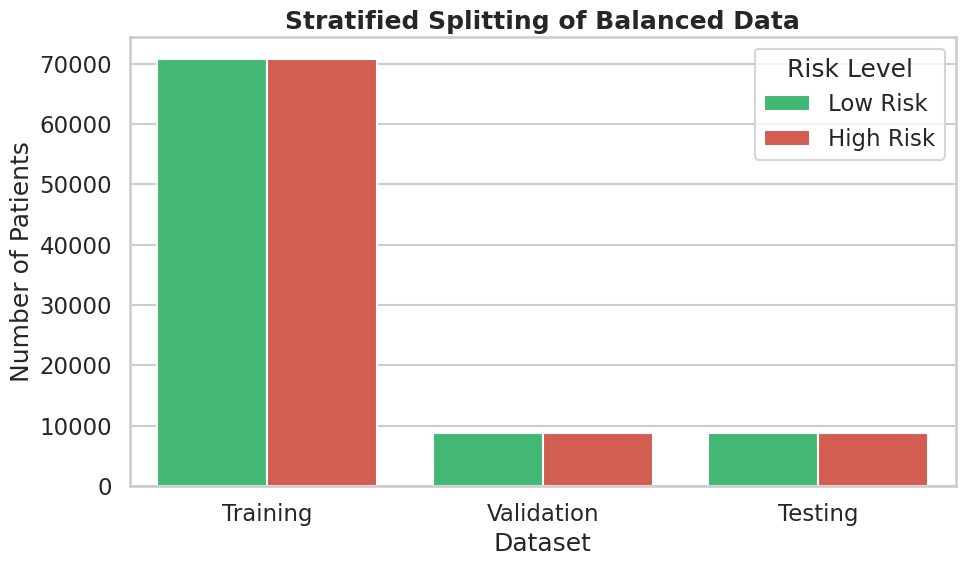

In [19]:
# ==============================================================================
# CELL 3: DATA BALANCING & STRATIFIED SPLITTING
# ==============================================================================
print("Resolving Class Imbalance via Oversampling...")

# Separate majority and minority classes
df_majority = df[df.High_Fall_Risk == 0]
df_minority = df[df.High_Fall_Risk == 1]

# Upsample minority class to match majority
df_minority_upsampled = df_minority.sample(len(df_majority), replace=True, random_state=42)
df_balanced = pd.concat([df_majority, df_minority_upsampled])

print(f"✅ Balanced Dataset Shape: {df_balanced.shape}")

# Define Features (X) and Target (y)
X_bal = df_balanced.drop(columns=['High_Fall_Risk'])
y_bal = df_balanced['High_Fall_Risk']

# Stratified Splitting (80% Train, 10% Validation, 10% Test)
X_temp, X_test, y_temp, y_test = train_test_split(X_bal, y_bal, test_size=0.10, random_state=42, stratify=y_bal)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=42, stratify=y_temp)

print("\n--- Data Split Summary ---")
print(f"Training Set:   {X_train.shape[0]} records")
print(f"Validation Set: {X_val.shape[0]} records")
print(f"Testing Set:    {X_test.shape[0]} records")

# Plot the balance across splits
split_data = pd.DataFrame({
    'Dataset': ['Training', 'Training', 'Validation', 'Validation', 'Testing', 'Testing'],
    'Risk Level': ['Low Risk', 'High Risk', 'Low Risk', 'High Risk', 'Low Risk', 'High Risk'],
    'Count': [
        (y_train == 0).sum(), (y_train == 1).sum(),
        (y_val == 0).sum(), (y_val == 1).sum(),
        (y_test == 0).sum(), (y_test == 1).sum()
    ]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=split_data, x='Dataset', y='Count', hue='Risk Level', palette=colors)
plt.title("Stratified Splitting of Balanced Data", fontweight='bold')
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

Generating Clinical Visualizations...


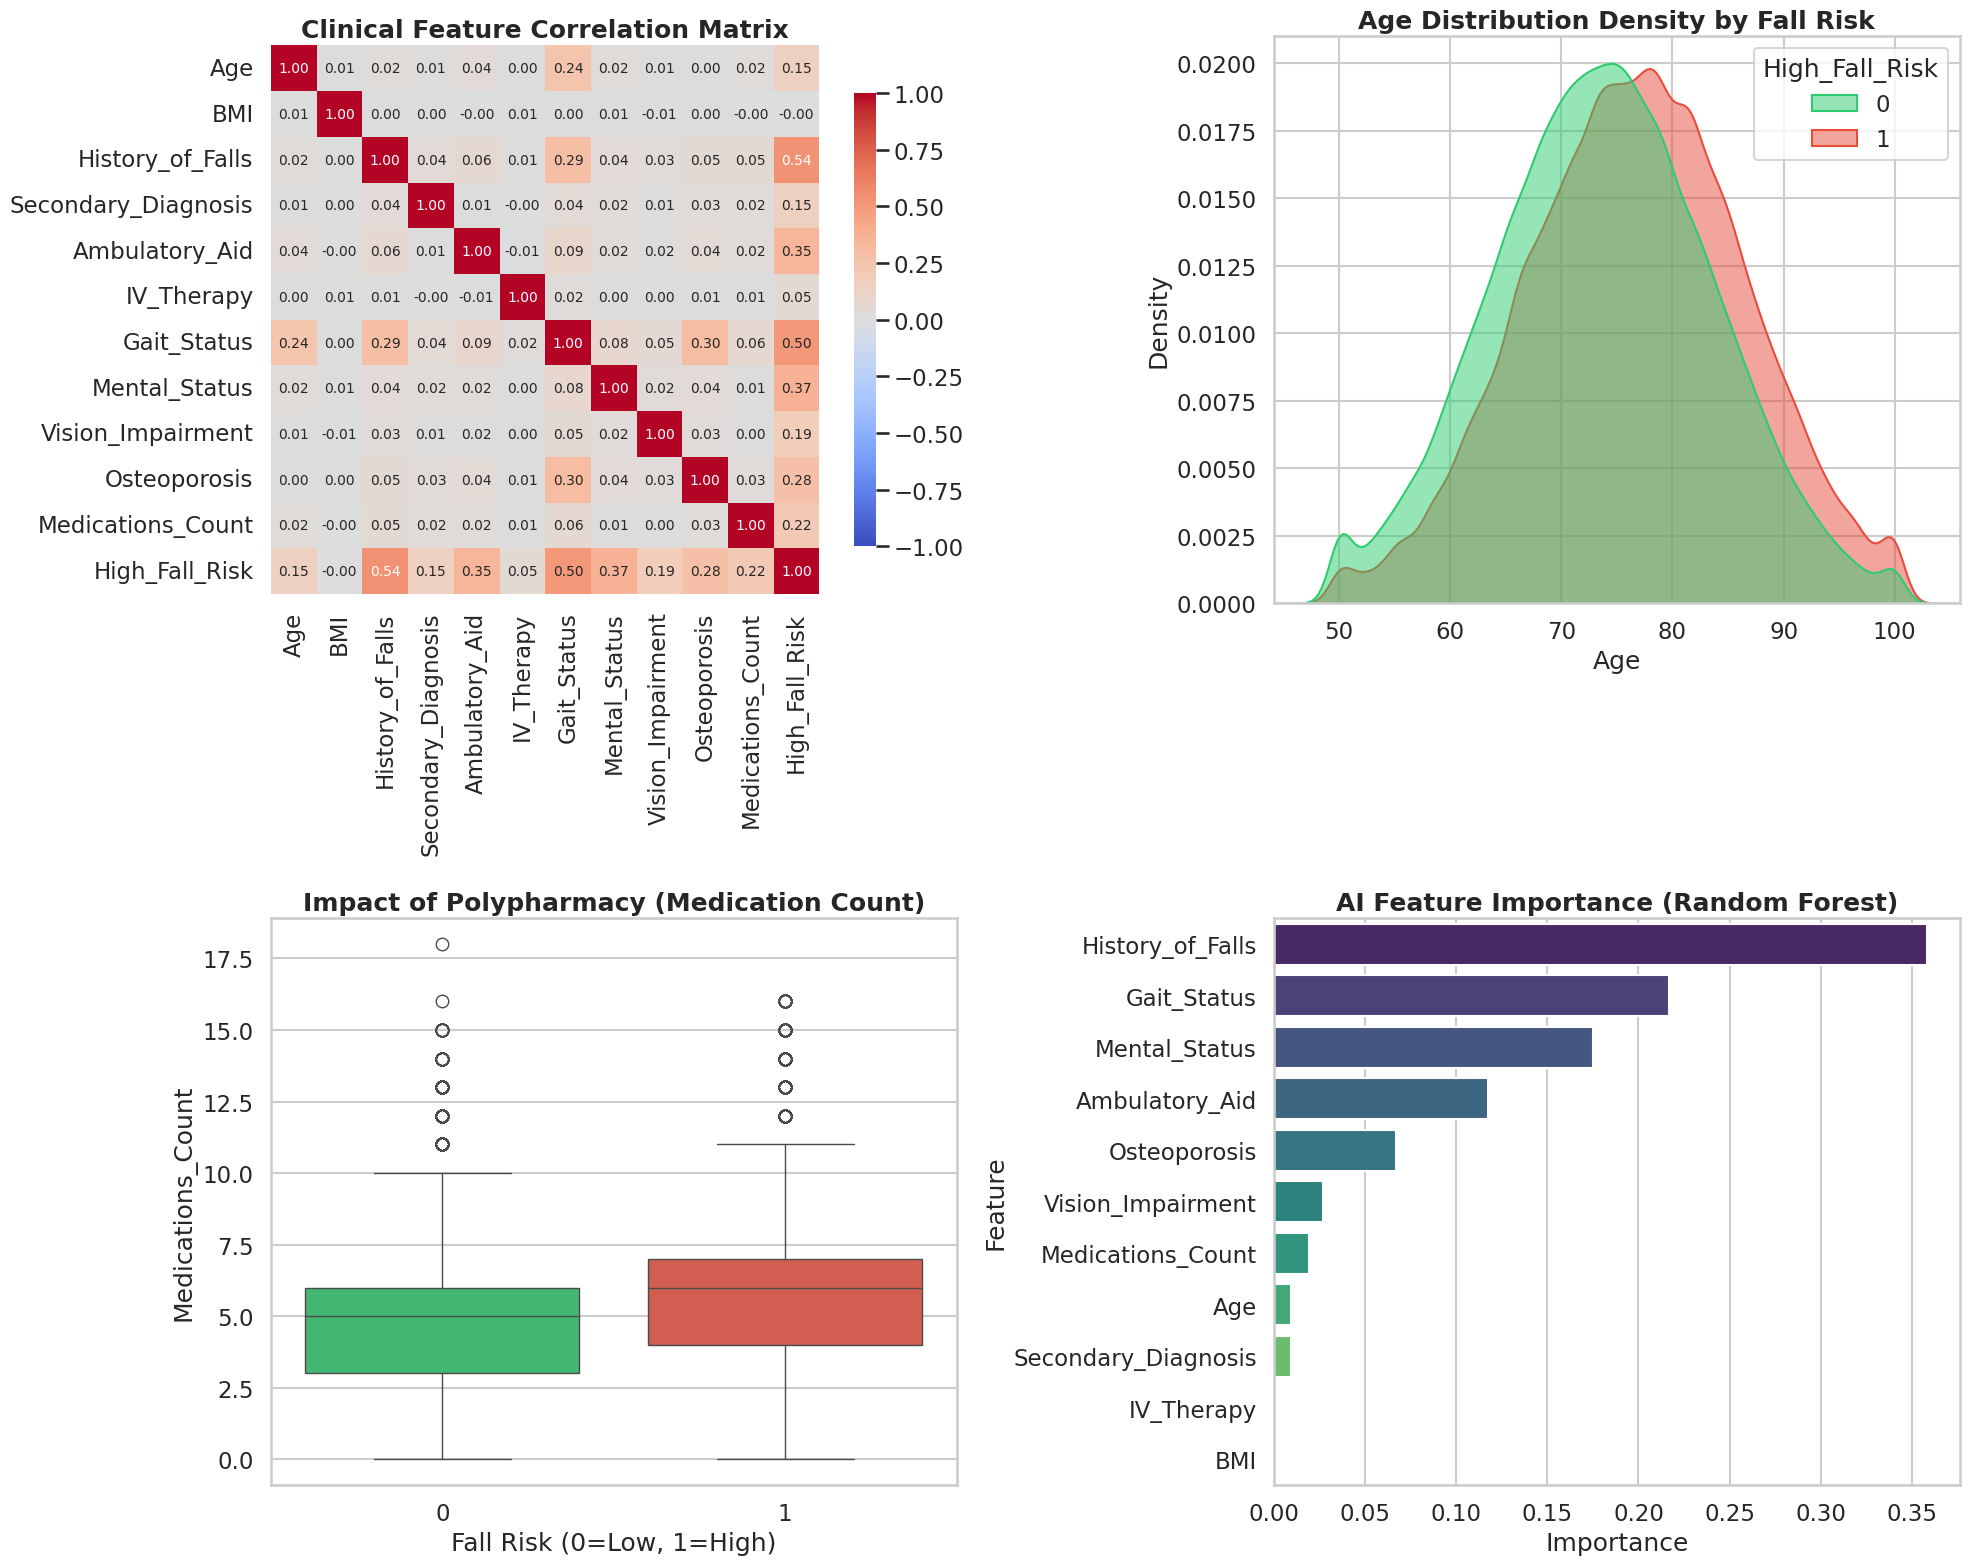

In [20]:
# ==============================================================================
# CELL 4: EXPLORATORY DATA ANALYSIS (EDA) & XAI
# ==============================================================================
print("Generating Clinical Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Correlation Heatmap
sns.heatmap(df_balanced.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            square=True, ax=axes[0, 0], cbar_kws={"shrink": .8}, annot_kws={"size": 10})
axes[0, 0].set_title("Clinical Feature Correlation Matrix", fontweight='bold')

# 2. Age Density Plot
sns.kdeplot(data=df_balanced, x='Age', hue='High_Fall_Risk', fill=True, palette=colors, alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_title("Age Distribution Density by Fall Risk", fontweight='bold')

# 3. Polypharmacy Boxplot
sns.boxplot(data=df_balanced, x='High_Fall_Risk', y='Medications_Count', palette=colors, ax=axes[1, 0])
axes[1, 0].set_title("Impact of Polypharmacy (Medication Count)", fontweight='bold')
axes[1, 0].set_xlabel("Fall Risk (0=Low, 1=High)")

# 4. Feature Importance (Explainable AI)
rf = RandomForestClassifier(n_estimators=50, random_state=42, max_depth=5, n_jobs=-1)
rf.fit(X_train, y_train)
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)

sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title("AI Feature Importance (Random Forest)", fontweight='bold')

plt.tight_layout()
plt.show()

Training HistGradientBoosting Classifier...
Training on Balanced Data: 141664 samples
Testing on Imbalanced Data (Real World): 20000 samples


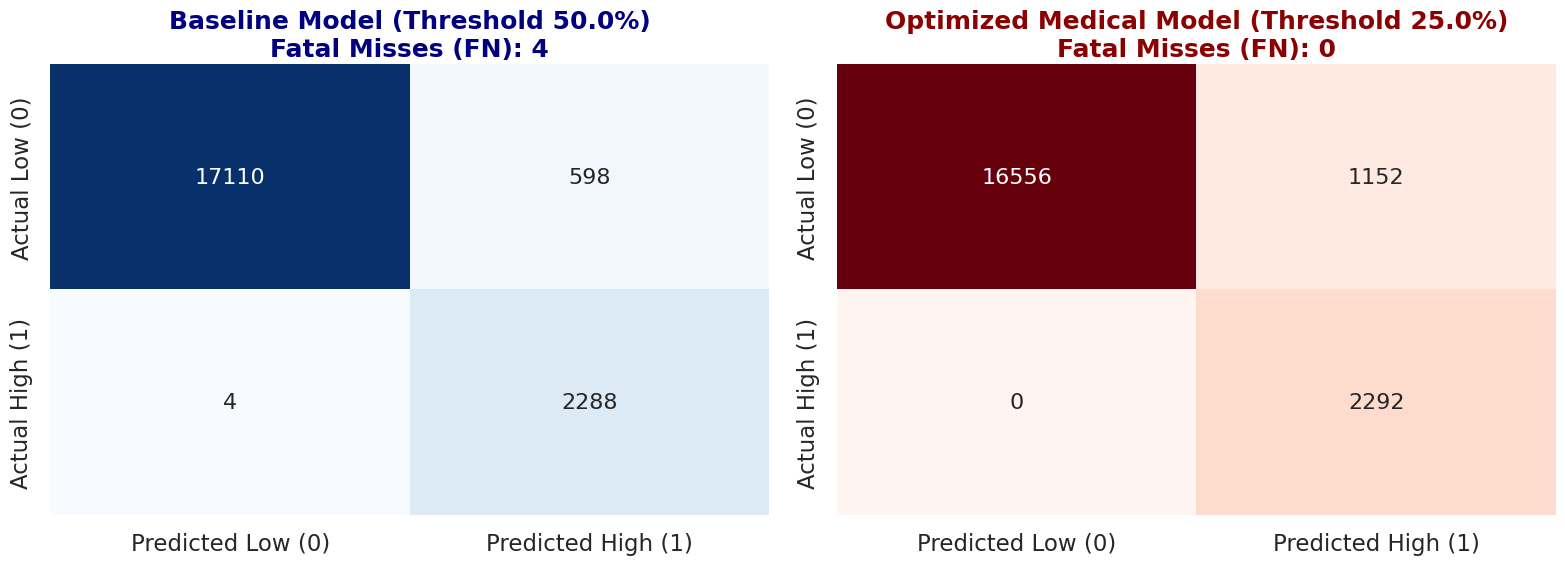


--- Final Model Performance (Medical Threshold) ---
               precision    recall  f1-score   support

 Low Risk (0)       1.00      0.93      0.97     17708
High Risk (1)       0.67      1.00      0.80      2292

     accuracy                           0.94     20000
    macro avg       0.83      0.97      0.88     20000
 weighted avg       0.96      0.94      0.95     20000



In [34]:
# ==============================================================================
# CELL 5: MODEL TRAINING & CLINICAL THRESHOLD OPTIMIZATION
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report

print("Training HistGradientBoosting Classifier...")

# 1. Start with the original UNBALANCED dataframe (df)
X = df.drop(columns=['High_Fall_Risk'])
y = df['High_Fall_Risk']

# 2. Split FIRST (Keep Test set realistic and imbalanced)
X_train_temp, X_test, y_train_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Balance ONLY the Training Set
train_data = pd.concat([X_train_temp, y_train_temp], axis=1)
train_majority = train_data[train_data.High_Fall_Risk == 0]
train_minority = train_data[train_data.High_Fall_Risk == 1]

# Upsample the minority class in the training set
train_minority_upsampled = train_minority.sample(len(train_majority), replace=True, random_state=42)
train_balanced = pd.concat([train_majority, train_minority_upsampled])

# Define balanced training features/target
X_train = train_balanced.drop(columns=['High_Fall_Risk'])
y_train = train_balanced['High_Fall_Risk']

print(f"Training on Balanced Data: {len(y_train)} samples")
print(f"Testing on Imbalanced Data (Real World): {len(y_test)} samples")

# 4. Initialize and train model
model = HistGradientBoostingClassifier(random_state=42, max_iter=100)
model.fit(X_train, y_train)

# Predict probabilities on the unseen TEST set
y_prob = model.predict_proba(X_test)[:, 1]

# Apply two different decision boundaries (Thresholds)
THRESHOLD_STANDARD = 0.50
THRESHOLD_MEDICAL = 0.25

y_pred_standard = (y_prob >= THRESHOLD_STANDARD).astype(int)
y_pred_medical = (y_prob >= THRESHOLD_MEDICAL).astype(int)

# Calculate Confusion Matrices explicitly ensuring labels [0, 1] are used
cm_standard = confusion_matrix(y_test, y_pred_standard, labels=[0, 1])
cm_medical = confusion_matrix(y_test, y_pred_medical, labels=[0, 1])

# Plot the Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_standard, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Predicted Low (0)', 'Predicted High (1)'],
            yticklabels=['Actual Low (0)', 'Actual High (1)'], annot_kws={"size": 16})
# The False Negative is now clearly at [1, 0] -> Actual High, Predicted Low
axes[0].set_title(f"Baseline Model (Threshold {THRESHOLD_STANDARD*100}%)\nFatal Misses (FN): {cm_standard[1,0]}", fontweight='bold', color='navy')

sns.heatmap(cm_medical, annot=True, fmt='d', cmap='Reds', ax=axes[1], cbar=False,
            xticklabels=['Predicted Low (0)', 'Predicted High (1)'],
            yticklabels=['Actual Low (0)', 'Actual High (1)'], annot_kws={"size": 16})
axes[1].set_title(f"Optimized Medical Model (Threshold {THRESHOLD_MEDICAL*100}%)\nFatal Misses (FN): {cm_medical[1,0]}", fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

print("\n--- Final Model Performance (Medical Threshold) ---")
print(classification_report(y_test, y_pred_medical, target_names=['Low Risk (0)', 'High Risk (1)']))

In [ ]:
import joblib
import sklearn
from google.colab import files

print("--- 💾 SAVING MODEL (PORTABLE VERSION) ---")

# bundle كامل (model + version)
bundle = {
    "model": model,
    "sklearn_version": sklearn.__version__
}

model_filename = "fall_risk_model.joblib"

joblib.dump(bundle, model_filename)

print("✅ Saved successfully with metadata")
print("sklearn version:", sklearn.__version__)

print("⬇️ Downloading file...")
files.download(model_filename)

--- 💾 SAVING MODEL FOR PRODUCTION ---
✅ Model successfully saved as: fall_risk_model.joblib
⬇️ Downloading to your local machine...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>